# A Bayesian Network for Modeling and Explaining Diabaese Prediction


## Abstract
This project presents a Bayesian Network designed to model and explain the prediction of diabetes based on various health and lifestyle factors. The network incorporates variables such as age, body mass index (BMI), physical activity, family history, and blood glucose levels to provide a probabilistic framework for understanding the relationships between these factors and the likelihood of developing diabetes. By leveraging the principles of Bayesian inference, the model aims to offer insights into the contributing factors of diabetes, enabling healthcare professionals to make informed decisions regarding prevention and treatment strategies. The network also facilitates explainability by allowing users to visualize how changes in specific variables impact the overall risk of diabetes, thereby enhancing interpretability and trust in the predictions made by the model.

## Dataset Overview
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.


The dataset contains the following attributes:
| Attribute                     | Description                                      |
|-------------------------------|--------------------------------------------------|
| Pregnancies                   | Number of times pregnant                         |
| Glucose                       | Plasma glucose concentration a 2 hours in an oral glucose tolerance test |
| BloodPressure                 | Diastolic blood pressure (mm Hg)                 |
| SkinThickness                 | Triceps skin fold thickness (mm)                 |
| Insulin                       | 2-Hour serum insulin (mu U/ml)                   |
| BMI                           | Body mass index (weight in kg/(height in m)^2)
| DiabetesPedigreeFunction      | Diabetes pedigree function                        |
| Age                           | Age (years)                                      |
| Outcome                       | Class variable (0 or 1) indicating if the patient has diabetes (1) or not (0) |
The dataset consists of 768 instances, with 500 instances labeled as non-diabetic (0) and 268 instances labeled as diabetic (1). The features include both continuous and categorical variables, which will be used to construct the Bayesian Network for predicting diabetes.


## Importing Libraries 

In [12]:
import pgmpy as pg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler


## Reading the Dataset

In [5]:
# merging two csv files into one
df = pd.read_csv('data/diabetes.csv',sep=',')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## EDA

### statistics lookup of each feature

In [6]:
statistic = df.describe().round(2)
statistic.loc['range'] = statistic.loc['max'] - statistic.loc['min']
statistic.loc['variance'] = df.var().round(2)
statistic


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00
range,17.00,199.00,122.00,99.00,846.00,67.10,2.34,60.00,1.00
variance,11.35,1022.25,374.65,254.47,13281.18,62.16,0.11,138.30,0.23


## Corelleation Matrix

In [7]:

## Corelleation Matrix
correlation_matrix = df.corr()
correlation_matrix


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


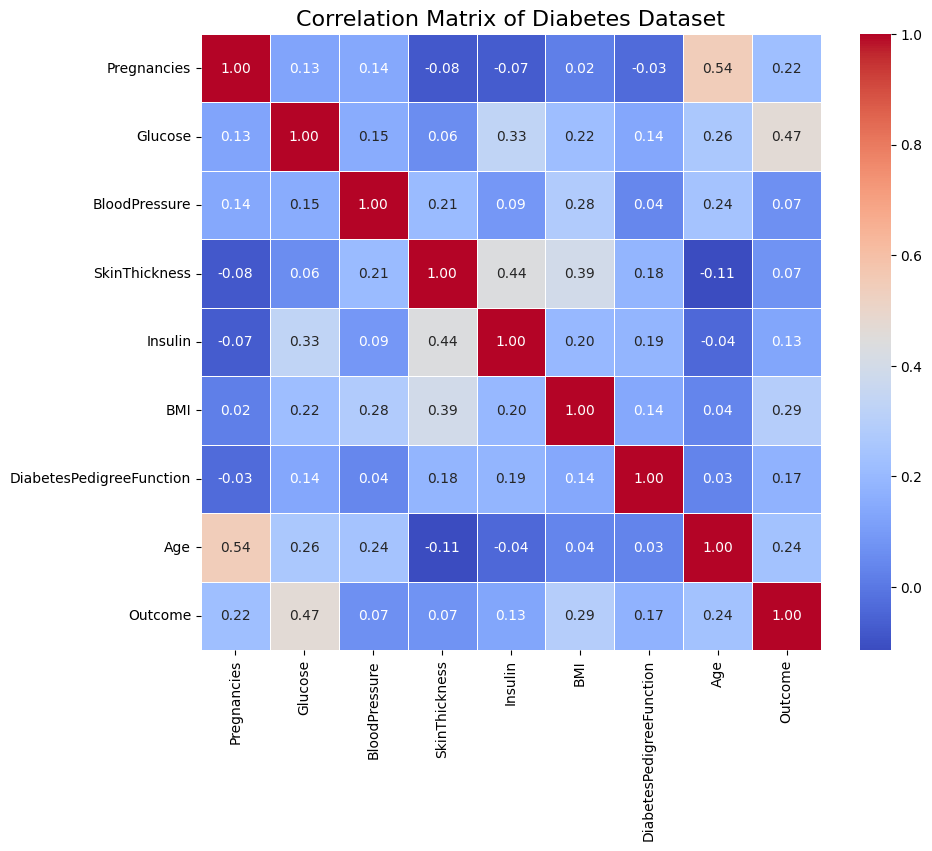

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidth=.5)
plt.title('Correlation Matrix of Diabetes Dataset', fontsize=16)
plt.savefig('correlation_matrix.png')
plt.show()

### Box Plot of each feature 

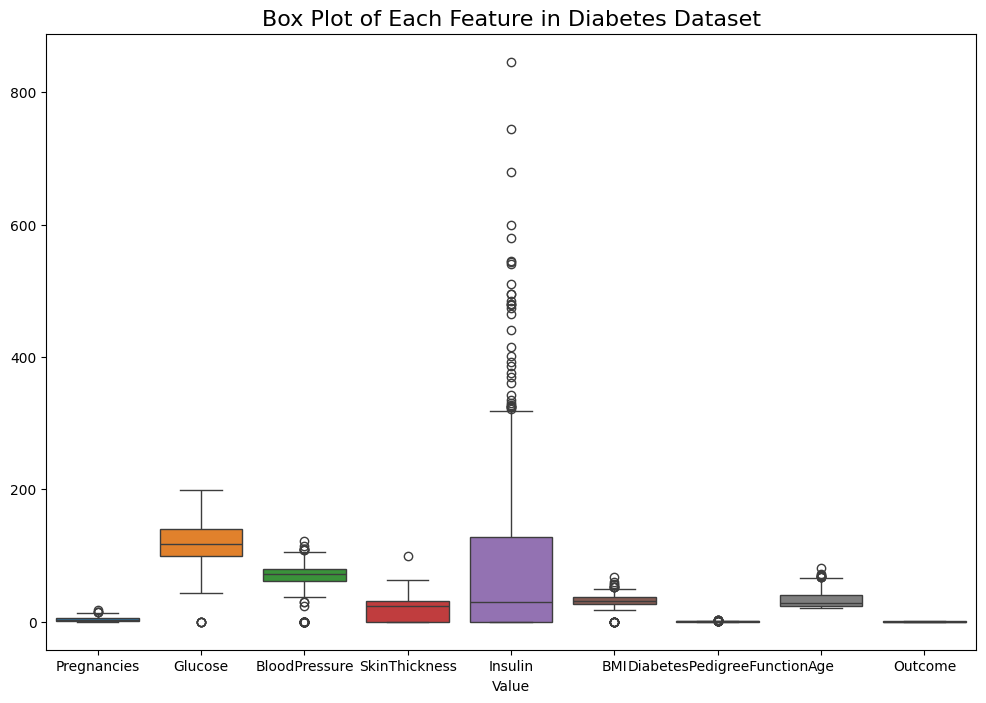

In [11]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title('Box Plot of Each Feature in Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_features.png')
plt.show()

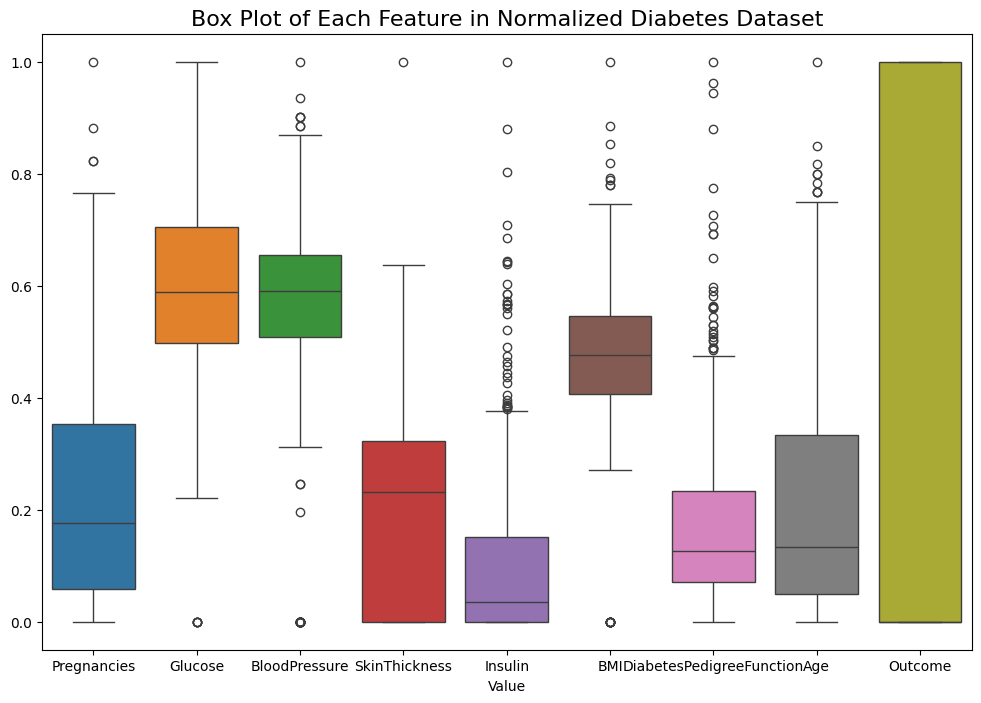

In [13]:
# normalize and check box plot again
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
plt.figure(figsize=(12, 8))
sns.boxplot(data=normalized_data)
plt.title('Box Plot of Each Feature in Normalized Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_normalized_features.png')
plt.show()

### Scatter Plot of each feature vs Outcome

<Figure size 640x480 with 0 Axes>

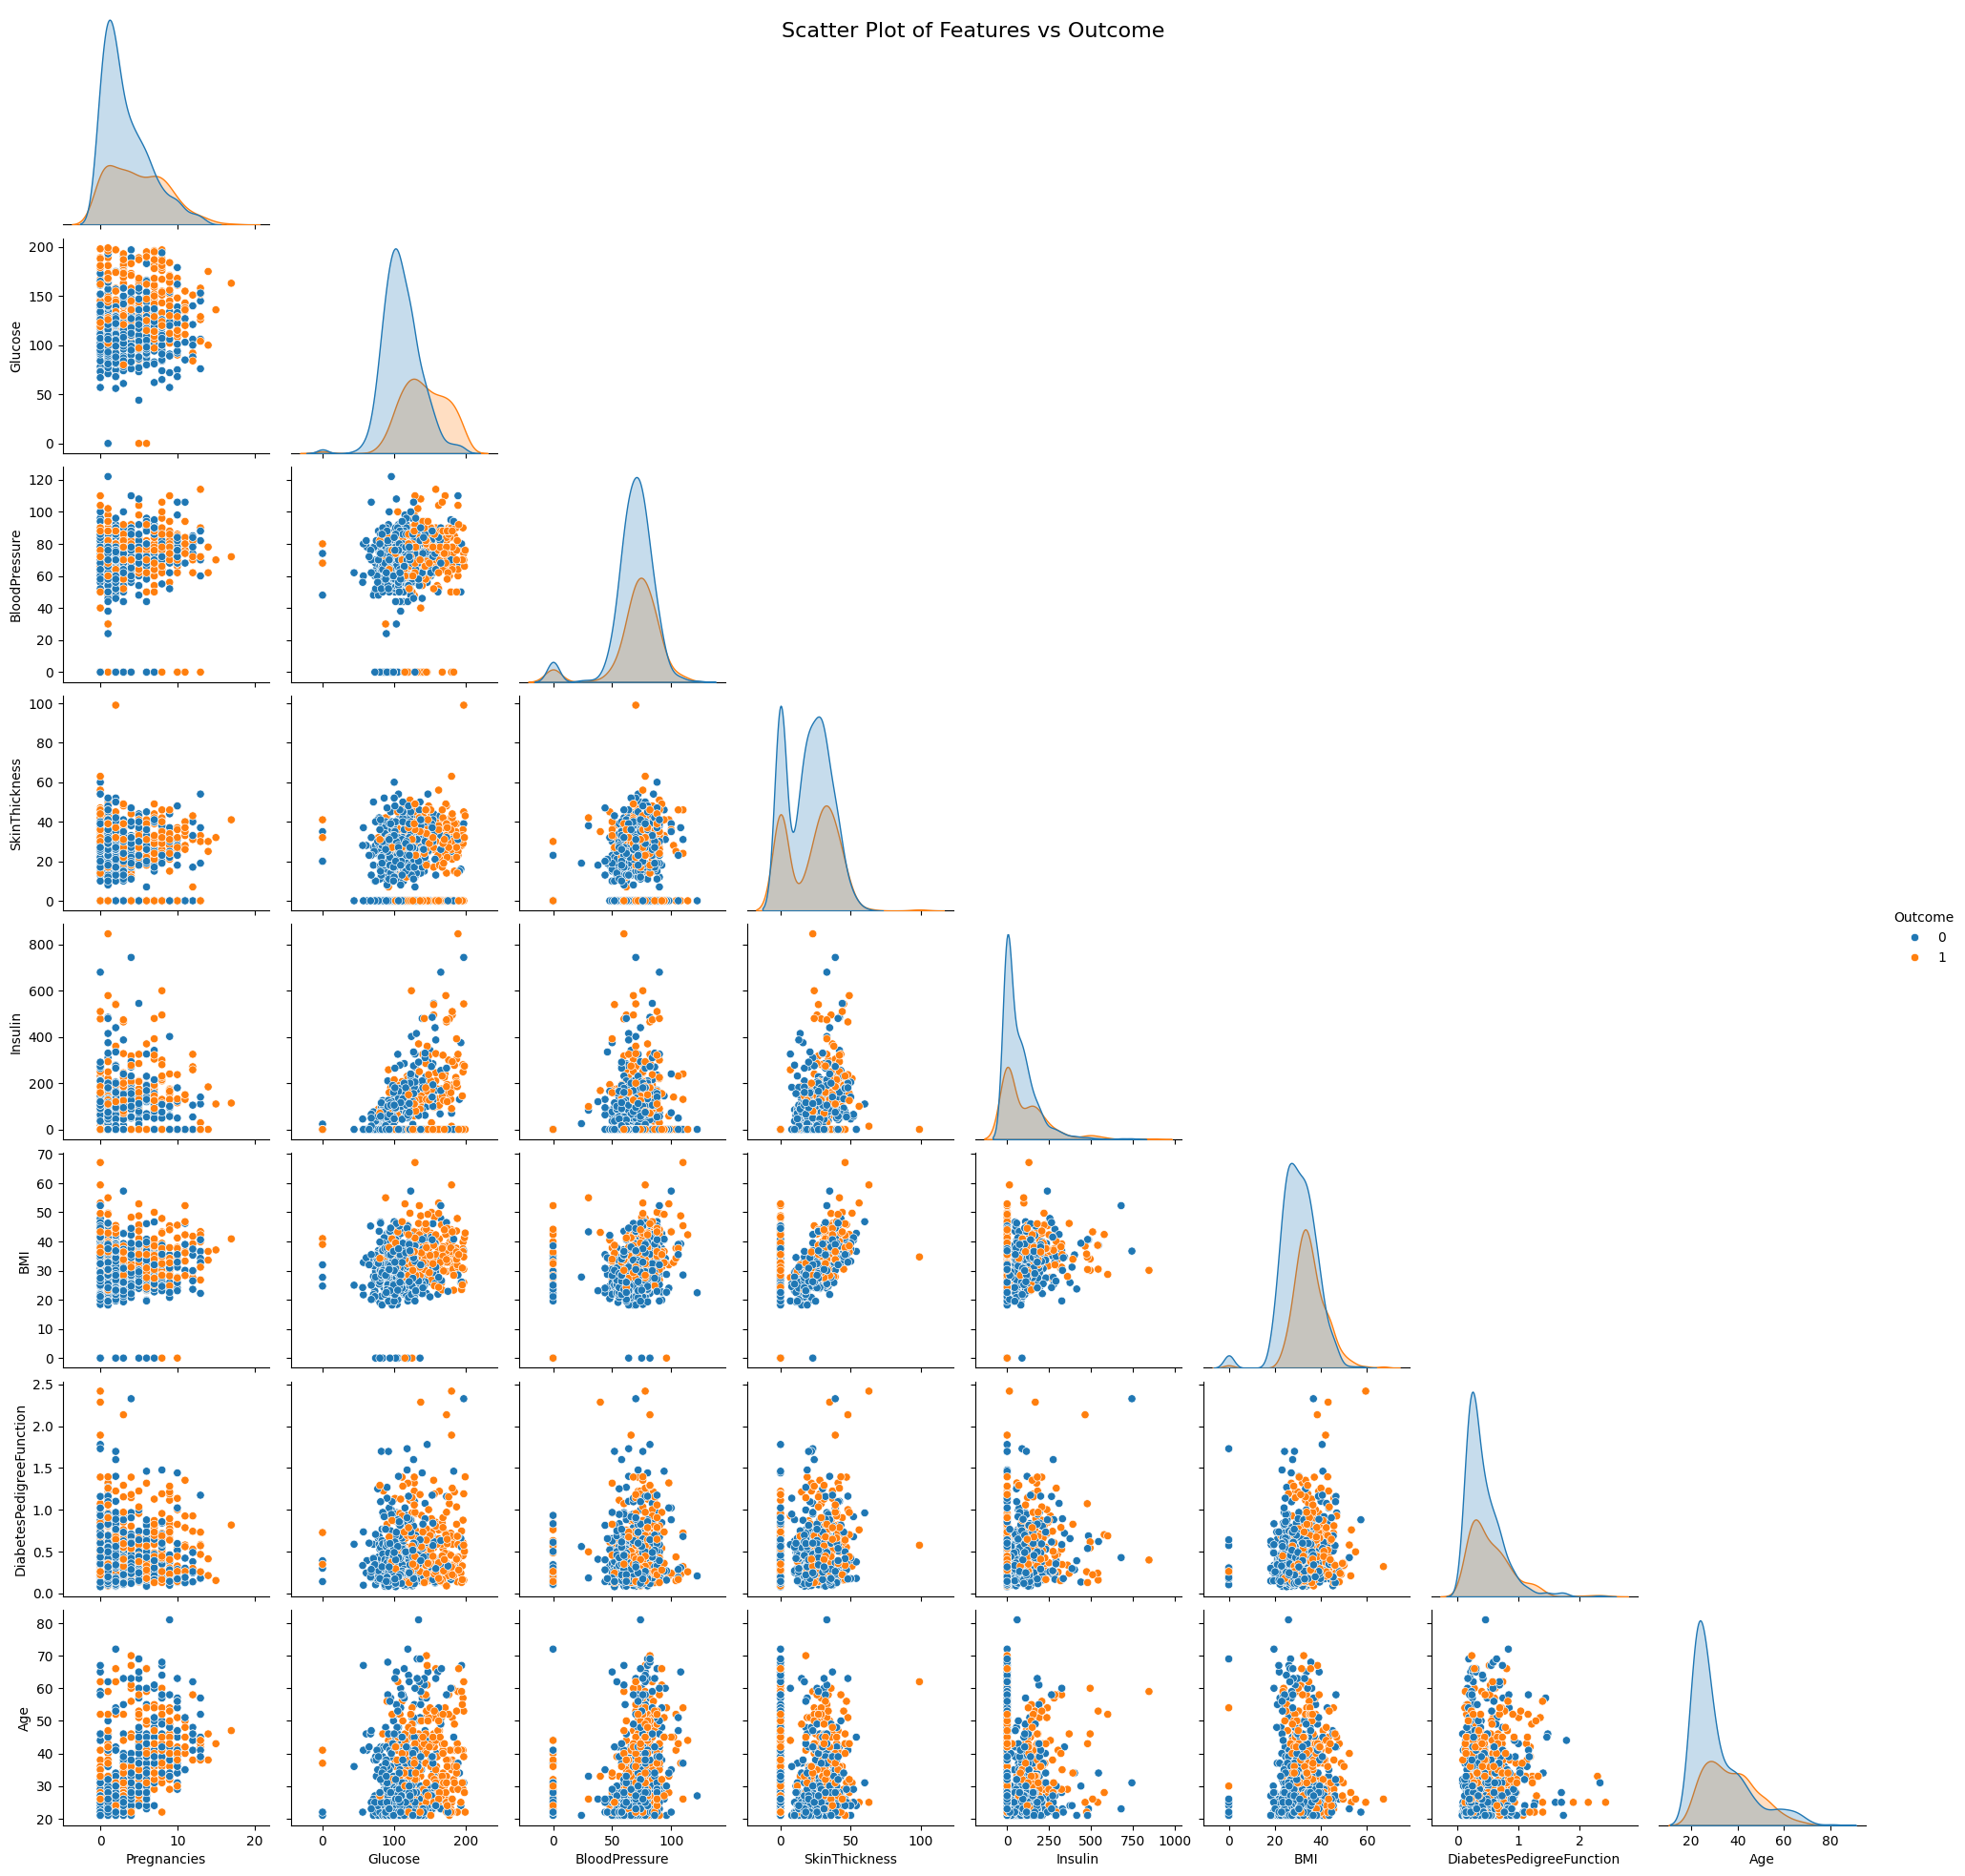

In [20]:
plt.figure()
sns.pairplot(
    df,
    vars=[df.columns[i] for i in range(len(df.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Scatter Plot of Features vs Outcome', fontsize=16)
plt.savefig('scatter_plot_features_vs_outcome.png')
plt.show()


### Check for missing Values

In [25]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

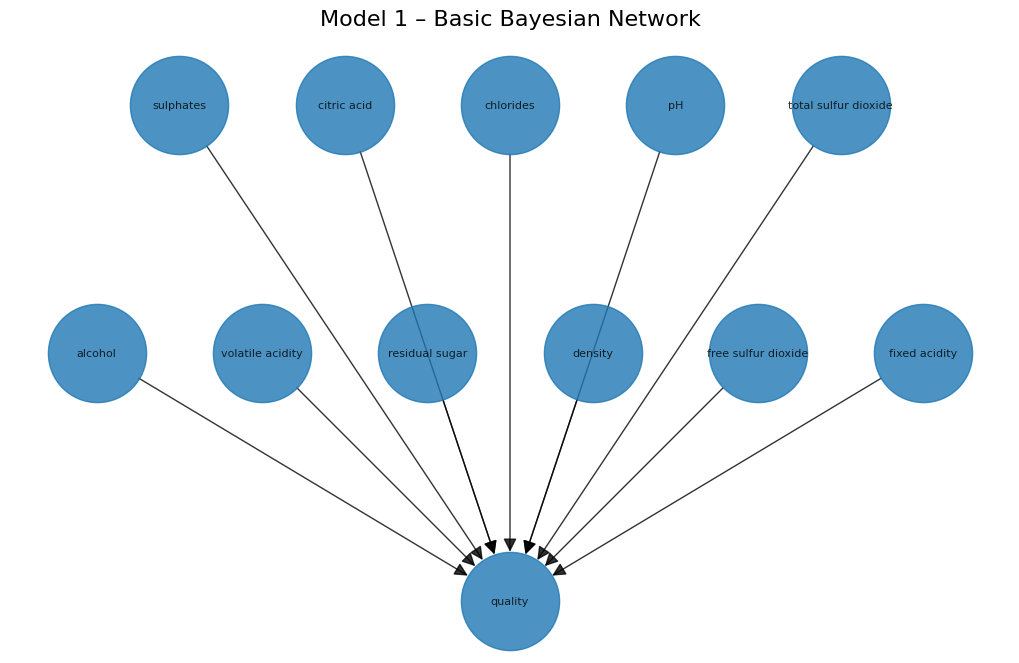

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt

basic_model = DiscreteBayesianNetwork([
    ('alcohol', 'quality'),
    ('sulphates', 'quality'),
    ('volatile acidity', 'quality'),
    ('citric acid', 'quality'),
    ('residual sugar', 'quality'),
    ('chlorides', 'quality'),
    ('density', 'quality'),
    ('pH', 'quality'),
    ('free sulfur dioxide', 'quality'),
    ('total sulfur dioxide', 'quality'),
    ('fixed acidity', 'quality')
])

pos_basic = {
    "alcohol": (0, 2), "sulphates": (2, 4), "volatile acidity": (4, 2),
    "citric acid": (6, 4), "residual sugar": (8, 2), "chlorides": (10, 4),
    "density": (12, 2), "pH": (14, 4), "free sulfur dioxide": (16, 2),
    "total sulfur dioxide": (18, 4), "fixed acidity": (20, 2),
    "quality": (10, 0)
}

plt.figure(figsize=(10, 6))
nx.draw(basic_model, pos_basic, with_labels=True, node_size=5000,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 1 – Basic Bayesian Network", fontsize=16, pad=20)
plt.show()


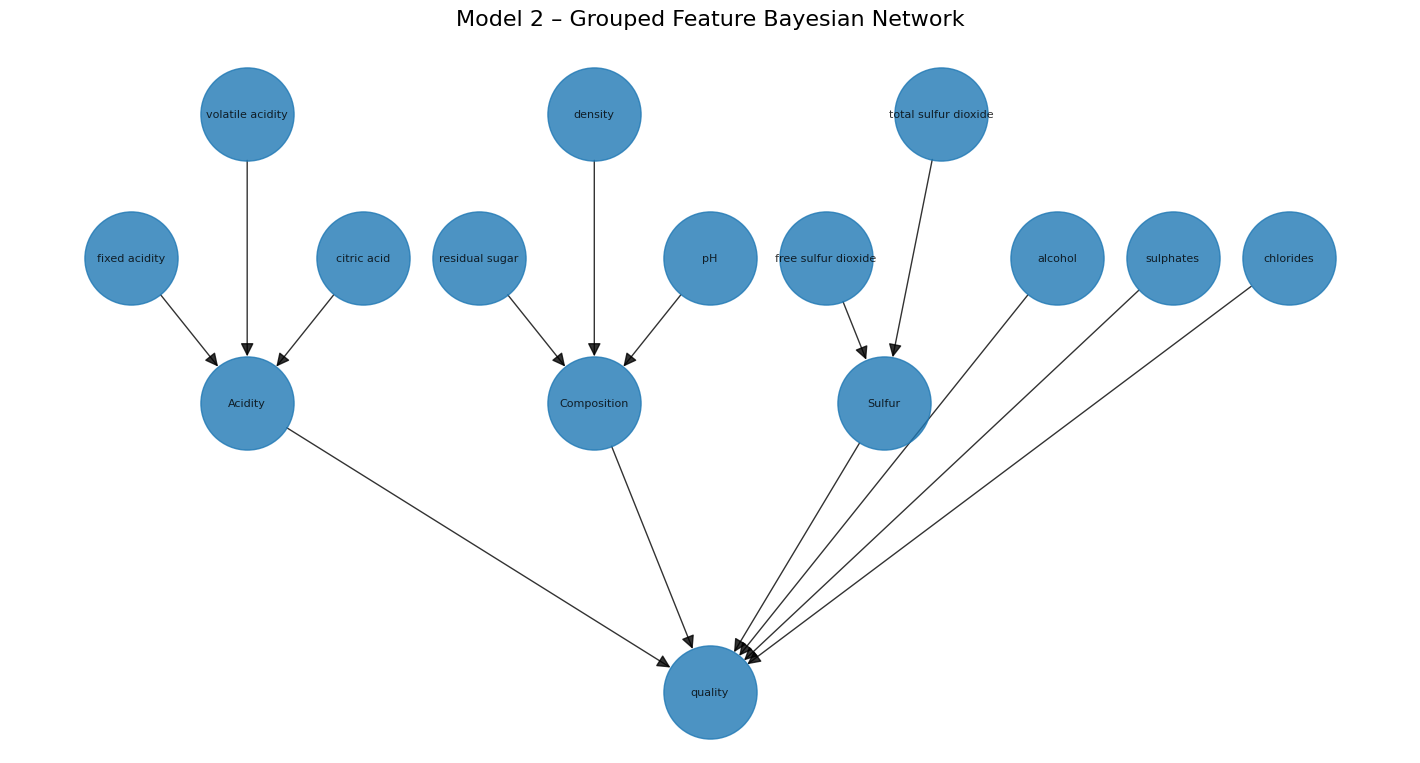

In [ ]:
grouped_model = DiscreteBayesianNetwork([
    ('fixed acidity', 'Acidity'),
    ('volatile acidity', 'Acidity'),
    ('citric acid', 'Acidity'),
    ('Acidity', 'quality'),

    ('residual sugar', 'Composition'),
    ('density', 'Composition'),
    ('pH', 'Composition'),
    ('Composition', 'quality'),

    ('free sulfur dioxide', 'Sulfur'),
    ('total sulfur dioxide', 'Sulfur'),
    ('Sulfur', 'quality'),

    ('alcohol', 'quality'),
    ('sulphates', 'quality'),
    ('chlorides', 'quality')
])

pos_grouped = {
    'fixed acidity': (0, 4), 'volatile acidity': (2, 5), 'citric acid': (4, 4),
    'Acidity': (2, 3),

    'residual sugar': (6, 4), 'density': (8, 5), 'pH': (10, 4),
    'Composition': (8, 3),

    'free sulfur dioxide': (12, 4), 'total sulfur dioxide': (14, 5),
    'Sulfur': (13, 3),

    'alcohol': (16, 4), 'sulphates': (18, 4), 'chlorides': (20, 4),

    'quality': (10, 1)
}

plt.figure(figsize=(14, 7))
nx.draw(grouped_model, pos_grouped, with_labels=True, node_size=4500,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 2 – Grouped Feature Bayesian Network", fontsize=16, pad=20)
plt.show()


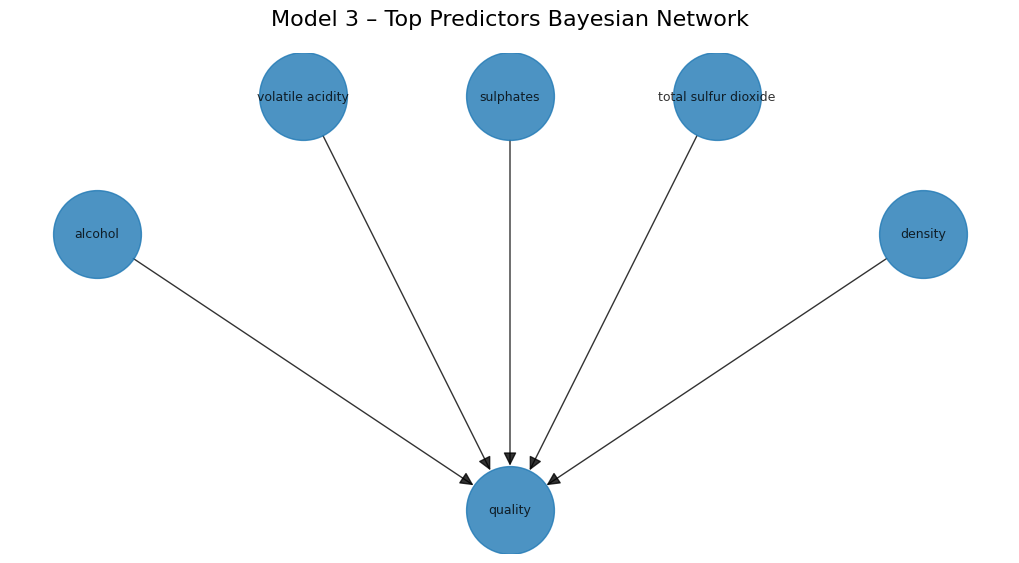

In [ ]:
top_predictor_model = DiscreteBayesianNetwork([
    ('alcohol', 'quality'),
    ('volatile acidity', 'quality'),
    ('sulphates', 'quality'),
    ('total sulfur dioxide', 'quality'),
    ('density', 'quality')
])

pos_top = {
    'alcohol': (0, 2), 'volatile acidity': (2, 3),
    'sulphates': (4, 3), 'total sulfur dioxide': (6, 3),
    'density': (8, 2),
    'quality': (4, 0)
}

plt.figure(figsize=(10, 5))
nx.draw(top_predictor_model, pos_top, with_labels=True, node_size=4000,
        font_size=9, arrowsize=20, alpha=0.8)

plt.title("Model 3 – Top Predictors Bayesian Network", fontsize=16, pad=20)
plt.show()


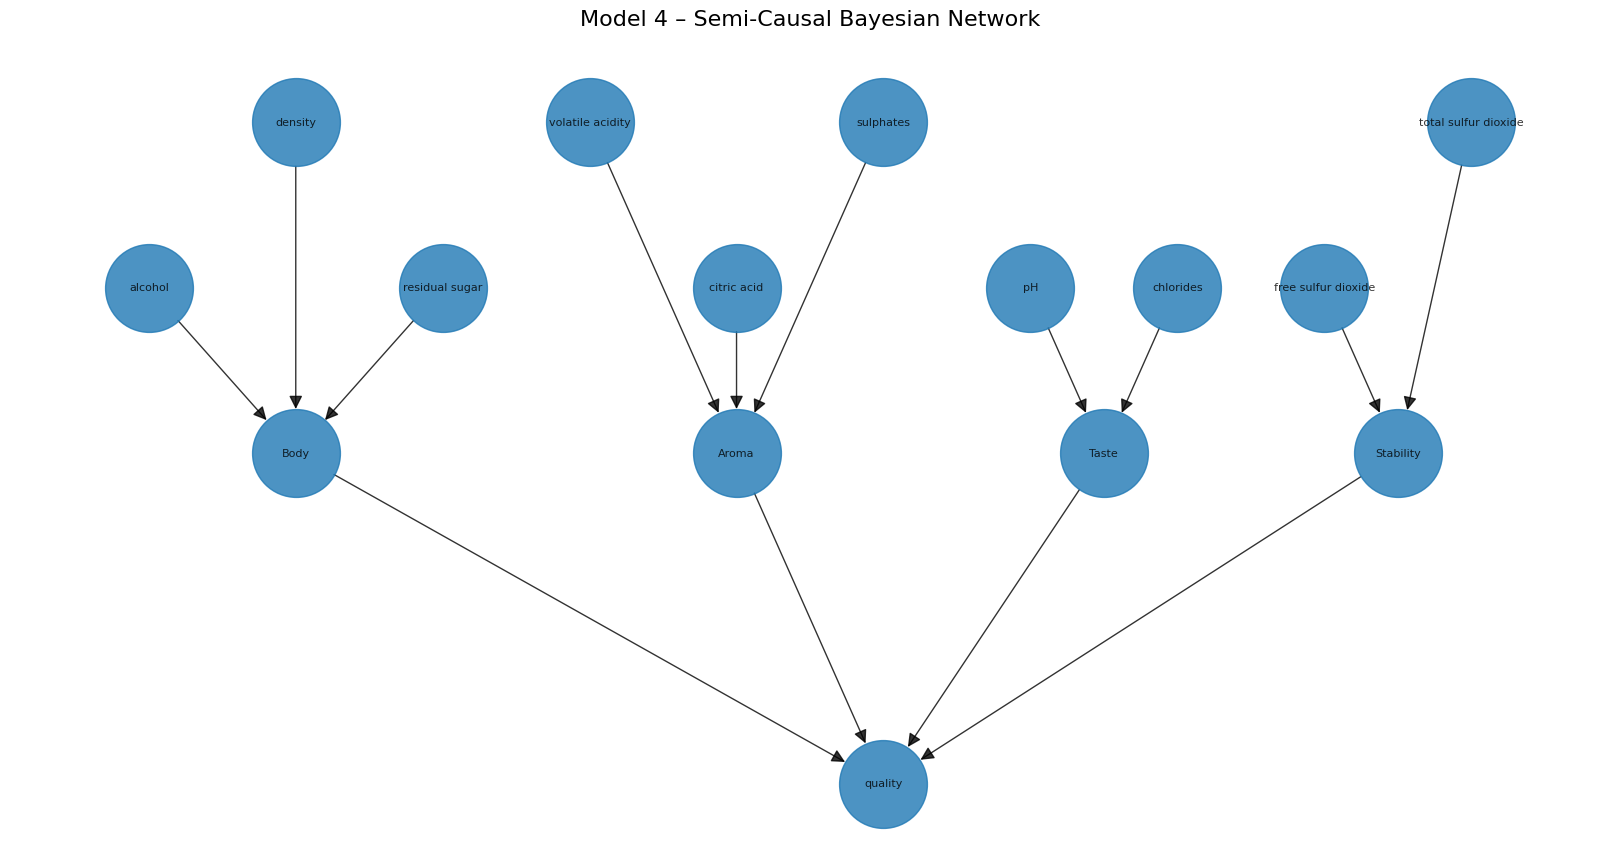

In [ ]:
semi_causal_model = DiscreteBayesianNetwork([
    ('alcohol', 'Body'),
    ('density', 'Body'),
    ('residual sugar', 'Body'),
    ('Body', 'quality'),

    ('volatile acidity', 'Aroma'),
    ('citric acid', 'Aroma'),
    ('sulphates', 'Aroma'),
    ('Aroma', 'quality'),

    ('pH', 'Taste'),
    ('chlorides', 'Taste'),
    ('Taste', 'quality'),

    ('free sulfur dioxide', 'Stability'),
    ('total sulfur dioxide', 'Stability'),
    ('Stability', 'quality'),
])

pos_semi = {
    'alcohol': (0, 4), 'density': (2, 5), 'residual sugar': (4, 4),
    'Body': (2, 3),

    'volatile acidity': (6, 5), 'citric acid': (8, 4), 'sulphates': (10, 5),
    'Aroma': (8, 3),

    'pH': (12, 4), 'chlorides': (14, 4),
    'Taste': (13, 3),

    'free sulfur dioxide': (16, 4), 'total sulfur dioxide': (18, 5),
    'Stability': (17, 3),

    'quality': (10, 1)
}

plt.figure(figsize=(16, 8))
nx.draw(semi_causal_model, pos_semi, with_labels=True, node_size=4000,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 4 – Semi-Causal Bayesian Network", fontsize=16, pad=20)
plt.show()


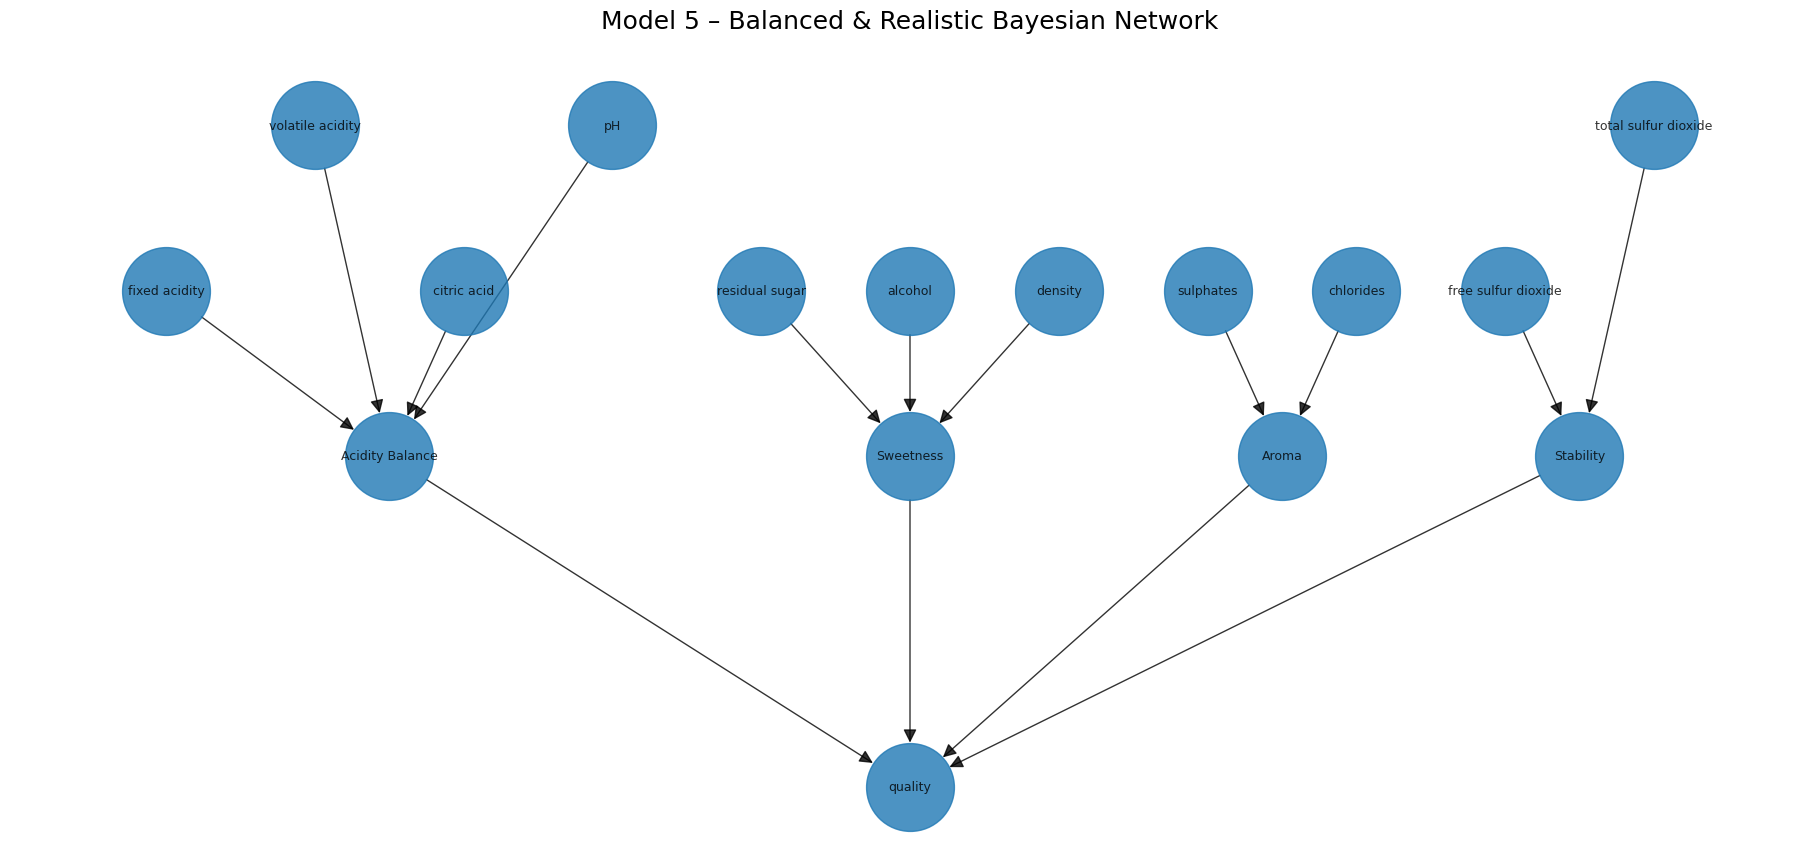

In [ ]:
best_model = DiscreteBayesianNetwork([
    ('fixed acidity', 'Acidity Balance'),
    ('volatile acidity', 'Acidity Balance'),
    ('citric acid', 'Acidity Balance'),
    ('pH', 'Acidity Balance'),
    ('Acidity Balance', 'quality'),

    ('residual sugar', 'Sweetness'),
    ('alcohol', 'Sweetness'),
    ('density', 'Sweetness'),
    ('Sweetness', 'quality'),

    ('sulphates', 'Aroma'),
    ('chlorides', 'Aroma'),
    ('Aroma', 'quality'),

    ('free sulfur dioxide', 'Stability'),
    ('total sulfur dioxide', 'Stability'),
    ('Stability', 'quality'),
])

pos_best = {
    'fixed acidity': (0, 4), 'volatile acidity': (2, 5), 'citric acid': (4, 4),
    'pH': (6, 5), 'Acidity Balance': (3, 3),

    'residual sugar': (8, 4), 'alcohol': (10, 4), 'density': (12, 4),
    'Sweetness': (10, 3),

    'sulphates': (14, 4), 'chlorides': (16, 4),
    'Aroma': (15, 3),

    'free sulfur dioxide': (18, 4), 'total sulfur dioxide': (20, 5),
    'Stability': (19, 3),

    'quality': (10, 1)
}

plt.figure(figsize=(18, 8))
nx.draw(best_model, pos_best, with_labels=True, node_size=4000,
        font_size=9, arrowsize=20, alpha=0.8)

plt.title("Model 5 – Balanced & Realistic Bayesian Network", fontsize=18, pad=20)
plt.show()


In [ ]:
binned_data["quality"]

0       1
1       1
2       1
3       2
4       1
       ..
6492    2
6493    1
6494    2
6495    3
6496    2
Name: quality, Length: 6497, dtype: int64

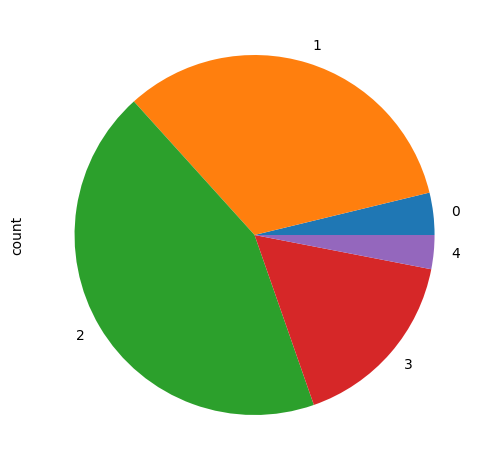

In [ ]:
binned_data["quality"].value_counts().sort_index().plot(kind='pie')
plt.tight_layout()
plt.show()

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, TreeSearch, BDeu, MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
from pgmpy.independencies import IndependenceAssertion


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fixed acidity': 'N', 'volatile acidity': 'N', 'citric acid': 'N', 'residual sugar': 'N', 'chlorides': 'N', 'free sulfur dioxide': 'N', 'total sulfur dioxide': 'N', 'density': 'N', 'pH': 'N', 'sulphates': 'N', 'alcohol': 'N', 'quality': 'N'}


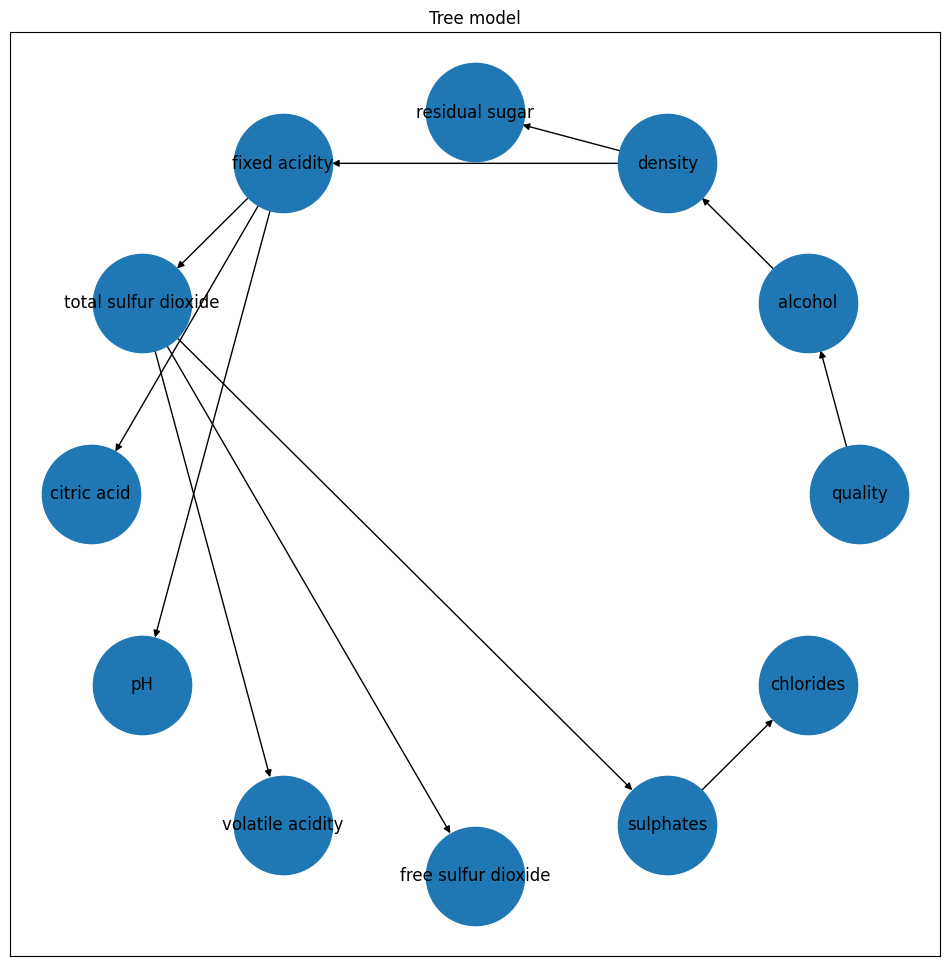

In [ ]:
ts = TreeSearch(data=binned_data, root_node='quality')
tree_model = ts.estimate(show_progress=False)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
nx.draw_networkx(tree_model, pos=nx.drawing.layout.circular_layout(tree_model), ax=ax, node_size=5000)
fig.savefig('tree')
ax.set_title('Tree model')
tree_model = DiscreteBayesianNetwork(tree_model.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fixed acidity': 'N', 'volatile acidity': 'N', 'citric acid': 'N', 'residual sugar': 'N', 'chlorides': 'N', 'free sulfur dioxide': 'N', 'total sulfur dioxide': 'N', 'density': 'N', 'pH': 'N', 'sulphates': 'N', 'alcohol': 'N', 'quality': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fixed acidity': 'N', 'volatile acidity': 'N', 'citric acid': 'N', 'residual sugar': 'N', 'chlorides': 'N', 'free sulfur dioxide': 'N', 'total sulfur dioxide': 'N', 'density': 'N', 'pH': 'N', 'sulphates': 'N', 'alcohol': 'N', 'quality': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fixed acidity': 'N', 'volatile acidity': 'N', 'citric acid': 'N', 'residual sugar': 'N', 'chlorides': 'N', 'free sulfur dioxide': 'N', 'total sulfur dioxide': 'N', 'density': 'N', 'pH': 'N', 'sulph

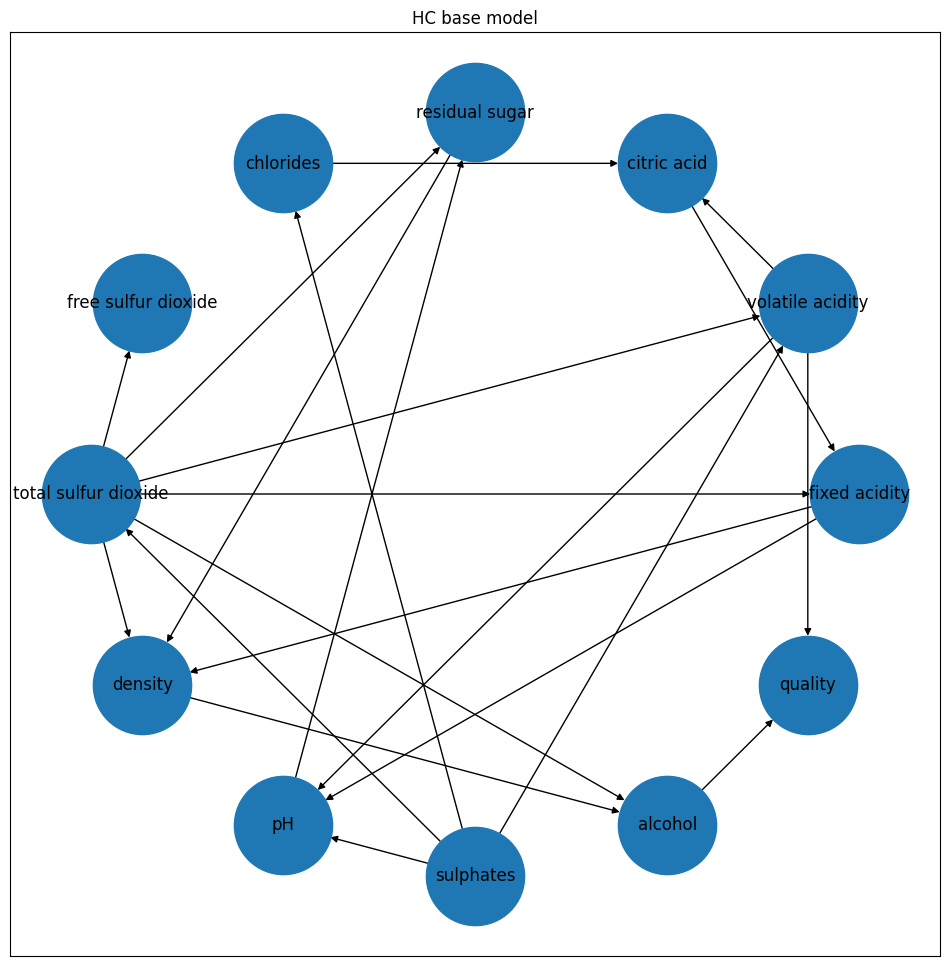

In [ ]:
scorer = BDeu(data=binned_data)
hc = HillClimbSearch(data=binned_data)
hc_base_model = hc.estimate(scoring_method=scorer, show_progress=False)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
nx.draw_networkx(hc_base_model, pos=nx.drawing.layout.circular_layout(hc_base_model), ax=ax, node_size=5000)
fig.savefig('hc_base')
ax.set_title('HC base model')
hc_base_model = DiscreteBayesianNetwork(hc_base_model.edges())

In [ ]:
#because of the small ram size we will fit the models one by one
# print('Fitting models to the data')
# print('Training basic_model')
# basic_model.fit(data=binned_data,estimator=MaximumLikelihoodEstimator)
# print('Training tree_model')
# tree_model.fit(data=binned_data,estimator=MaximumLikelihoodEstimator)
# print('Training hc model')
# hc_base_model.fit(data=binned_data,estimator=MaximumLikelihoodEstimator)
# print('Training grouped_model')
# grouped_model.fit(data=binned_data,estimator=MaximumLikelihoodEstimator)
# print('Training top_predictor_model')
# top_predictor_model.fit(data=binned_data,estimator=MaximumLikelihoodEstimator)
# print('Training best_model')
# best_model.fit(data=binned_data,estimator=MaximumLikelihoodEstimator)

In [ ]:

models = [('basic_model', basic_model),
          ('tree', tree_model),
          ('hc base', hc_base_model),]
          # ('grouped_model', grouped_model),
          # ('top_predictor_model', top_predictor_model),
          # ('semi_causal_model', semi_causal_model),
          # ('best_model', best_model)]
print('start training models')
for name, model in models:
    print(f'Computing CDTs for {name} model')
    model.fit(binned_data, estimator=MaximumLikelihoodEstimator)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fixed acidity': 'N', 'volatile acidity': 'N', 'citric acid': 'N', 'residual sugar': 'N', 'chlorides': 'N', 'free sulfur dioxide': 'N', 'total sulfur dioxide': 'N', 'density': 'N', 'pH': 'N', 'sulphates': 'N', 'alcohol': 'N', 'quality': 'N'}


start training models
Computing CDTs for basic_model model


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fixed acidity': 'N', 'volatile acidity': 'N', 'citric acid': 'N', 'residual sugar': 'N', 'chlorides': 'N', 'free sulfur dioxide': 'N', 'total sulfur dioxide': 'N', 'density': 'N', 'pH': 'N', 'sulphates': 'N', 'alcohol': 'N', 'quality': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'fixed acidity': 'N', 'volatile acidity': 'N', 'citric acid': 'N', 'residual sugar': 'N', 'chlorides': 'N', 'free sulfur dioxide': 'N', 'total sulfur dioxide': 'N', 'density': 'N', 'pH': 'N', 'sulphates': 'N', 'alcohol': 'N', 'quality': 'N'}


Computing CDTs for tree model
Computing CDTs for hc base model


In [ ]:
nodes = ['alcohol', 'sulphates', 'volatile acidity',
         'citric acid', 'residual sugar', 'chlorides',
         'density', 'pH', 'free sulfur dioxide',
         'total sulfur dioxide', 'fixed acidity', 'quality']
print('Considering nodes:', nodes)
for name, model in models:
    print(f'Analyzing model: {name}')
    print(f'The total number of valid independence assertions is {len(model.get_independencies().get_assertions())}')
    print(f'Local semantics of the current model:\n{model.local_independencies(nodes)}')
    print('Checking Markov blankets')
    for node in nodes:
        print(f'The Markov blanket of node {node} is {model.get_markov_blanket(node)}')
    print()

Considering nodes: ['alcohol', 'sulphates', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'density', 'pH', 'free sulfur dioxide', 'total sulfur dioxide', 'fixed acidity', 'quality']
Analyzing model: basic_model
The total number of valid independence assertions is 55
Local semantics of the current model:
(alcohol ⟂ fixed acidity, citric acid, pH, density, chlorides, residual sugar, volatile acidity, sulphates, free sulfur dioxide, total sulfur dioxide)
(sulphates ⟂ fixed acidity, citric acid, pH, density, chlorides, residual sugar, volatile acidity, alcohol, free sulfur dioxide, total sulfur dioxide)
(volatile acidity ⟂ fixed acidity, citric acid, pH, density, chlorides, residual sugar, alcohol, sulphates, free sulfur dioxide, total sulfur dioxide)
(citric acid ⟂ fixed acidity, pH, density, chlorides, residual sugar, volatile acidity, alcohol, sulphates, free sulfur dioxide, total sulfur dioxide)
(residual sugar ⟂ fixed acidity, citric acid, pH, density, chlorides, v

In [ ]:
inferences = [(name, VariableElimination(model)) for name, model in models]